# 32.2 · Joint angles and skeleton geometry

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain joint angles and skeleton geometry using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[24 · PyTorch for Computer Vision](../../24-pytorch-for-computer-vision/README.md), [27 · Object Detection](../../27-object-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Pose estimation locates keypoints such as joints. A skeleton connects selected keypoints into a geometric structure. The output can support motion visualization or repetition counting, but visibility, projection and landmark uncertainty limit interpretation.

## 2. Intuition

A joint angle uses two vectors meeting at the joint and the angle between them. Two-dimensional image angles depend on camera viewpoint and are not always anatomical three-dimensional angles. Normalize coordinates consistently and reject zero-length limbs rather than returning an arbitrary angle.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 32
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\theta=\arccos\left(\frac{u\cdot v}{\lVert u\rVert\lVert v\rVert}\right)
$$

u and v are limb vectors from the joint and θ their angle. Perpendicular vectors [1,0] and [0,1] give 90 degrees. Clamp the cosine to [−1,1] to handle floating-point roundoff.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
u, v = np.array([1.0, 0.0]), np.array([0.0, 1.0])
cosine = u @ v / (np.linalg.norm(u) * np.linalg.norm(v))
angle = np.degrees(np.arccos(np.clip(cosine, -1, 1)))
assert np.isclose(angle, 90)
print(angle)

90.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Heatmap decoding, angle computation and hysteresis are separate functions so each can be inspected and tested independently of a pose detector.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def pose(lesson, seed, amount):
    rng = np.random.default_rng(seed)
    y, x = np.indices((64, 64))
    true = np.array([31.4, 25.2])
    heat = np.exp(-((x - true[0]) ** 2 + (y - true[1]) ** 2) / (2 * 3**2))
    heat += rng.normal(0, 0.01 * amount, heat.shape)
    estimate = soft_argmax(heat, 0.05)
    angles = 105 + 65 * np.cos(np.linspace(0, 6 * np.pi, 120))
    count = count_repetitions(angles)
    return Result(
        "32 · Heatmaps, keypoints and repetition state",
        {"Noisy keypoint heatmap": heat},
        curves={"Elbow angle (degrees)": angles},
        metrics={
            "keypoint_error_px": float(np.linalg.norm(estimate - true)),
            "cycles_counted": count,
            "right_angle_degrees": joint_angle(
                np.array([0, 1]), np.array([0, 0]), np.array([1, 0])
            ),
        },
        notes="Keypoints and motion are generated. This does not estimate joints from a human photograph; use the optional MediaPipe adapter with explicit model assets.",
    )

{
  "keypoint_error_px": 0.04422947389927644,
  "cycles_counted": 3,
  "right_angle_degrees": 90.0
}
Keypoints and motion are generated. This does not estimate joints from a human photograph; use the optional MediaPipe adapter with explicit model assets.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/tracking.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.tracking import joint_angle

display(Code(inspect.getsource(joint_angle), language="python"))

def joint_angle(a, b, c):
    """Angle ABC in degrees; reject a zero-length limb."""
    u, v = np.asarray(a) - b, np.asarray(c) - b
    length = np.linalg.norm(u) * np.linalg.norm(v)
    if length < 1e-10:
        raise ValueError("Cannot measure an angle with a zero-length limb.")
    return float(np.degrees(np.arccos(np.clip(u @ v / length, -1, 1))))

## 8. Experiment

Add angular noise around the thresholds and compare a single threshold with hysteresis. Include an incomplete repetition.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "keypoint_error_px": 0.04422947389927644,
    "cycles_counted": 3,
    "right_angle_degrees": 90.0
  },
  "second_seed": {
    "keypoint_error_px": 0.08087599769270165,
    "cycles_counted": 3,
    "right_angle_degrees": 90.0
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

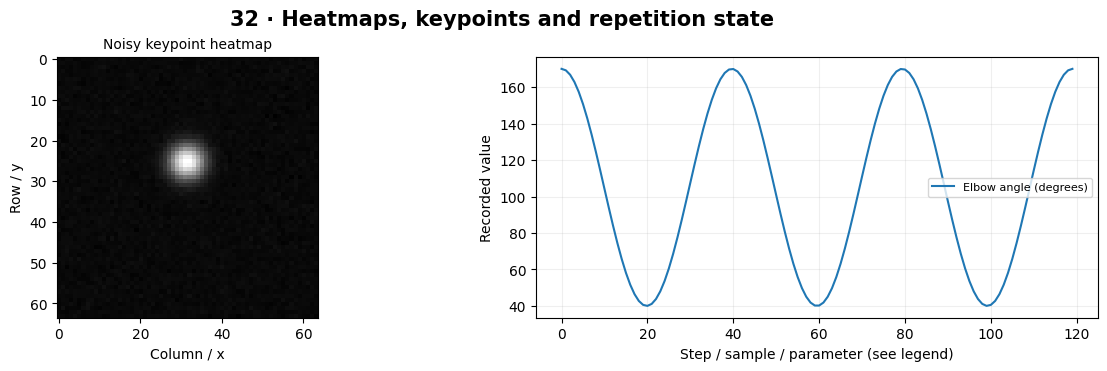

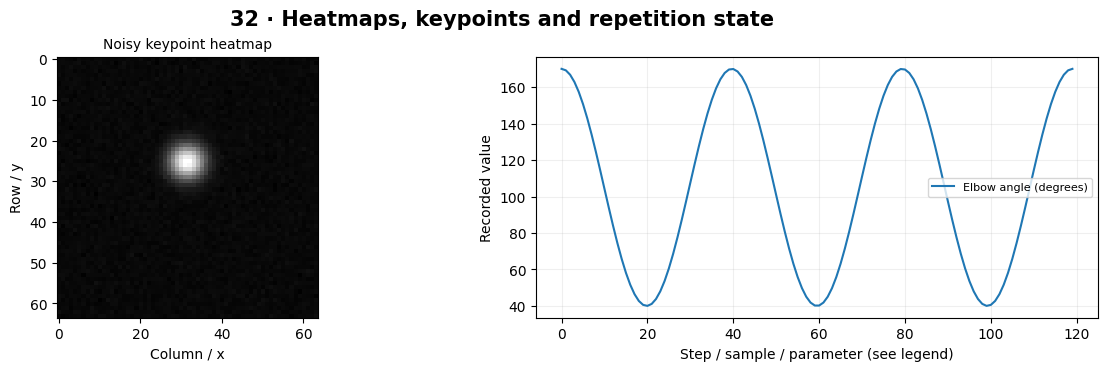

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Exercise Counter**. Visualize joints with uncertainty and safe exercise feedback. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A keypoint detector does not diagnose posture or health. Occluded joints can be guessed incorrectly.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Add angular noise around the thresholds and compare a single threshold with hysteresis. Include an incomplete repetition.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build an exercise counter that displays visible landmarks, tracks incomplete cycles and pauses when confidence is insufficient.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A joint angle uses two vectors meeting at the joint and the angle between them. Two-dimensional image angles depend on camera viewpoint and are not always anatomical three-dimensional angles. Normalize coordinates consistently and reject zero-length limbs rather than returning an arbitrary angle.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Temporal states and exercise counting** in this chapter.

[Primary reference](https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker/python) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)